In [14]:
#1
from scipy.stats import bernoulli, binom
from matplotlib.pyplot import bar, show, hist, grid, legend, xticks

In [15]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
#a
def deplasare(n,p):
    pozitii=[0]
    poz=0
    deplasari=bernoulli.rvs(p,size=n)
    for pas in deplasari:
        pas=int(pas)
        poz+=2*pas-1
        pozitii.append(poz)
    return pozitii

In [17]:
print(deplasare(50,0.5))

[0, -1, 0, -1, -2, -3, -4, -3, -4, -5, -6, -7, -6, -5, -6, -7, -8, -9, -10, -11, -10, -11, -10, -11, -10, -9, -10, -11, -10, -9, -10, -9, -10, -11, -10, -9, -10, -9, -8, -9, -8, -7, -6, -7, -6, -7, -6, -5, -4, -5, -4]


In [37]:
#b
def simulare_multipla(k, n, p):
    finale = []
    for _ in range(k):
        pozitii = deplasare(n, p)
        finale.append(pozitii[-1])

    bin_edges = [x + 0.5 for x in range(min(finale) - 1, max(finale) + 1)]
    hist(finale, bins=20)
    grid(True)
    show()

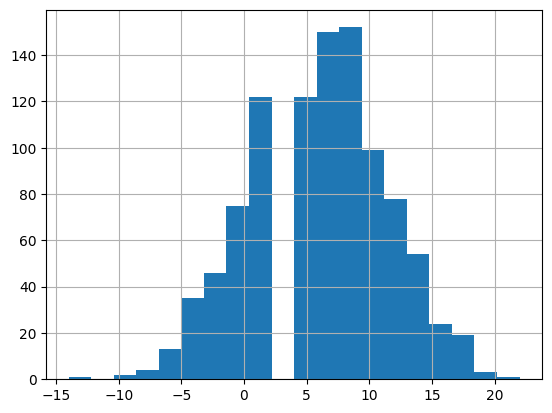

In [38]:
simulare_multipla(1000, 30, 0.6)


In [40]:
def deplasare_cerc(pasii, p, n):
    pozitii = [0]
    poz = 0
    deplasari = bernoulli.rvs(p, size=pasii)
    for pas in deplasari:
        pas=int(pas)
        poz = (poz + (2*pas - 1)) % n
        pozitii.append(poz)
    return pozitii

def simulare_multipla_cerc(k, pasii, p, n):
    finale = []
    for _ in range(k):
        pozitii = deplasare_cerc(pasii, p, n)
        finale.append(pozitii[-1])
    
    counts = [finale.count(i) for i in range(n)]
    bar(range(n), counts)
    xticks(range(n))
    grid(True)
    show()

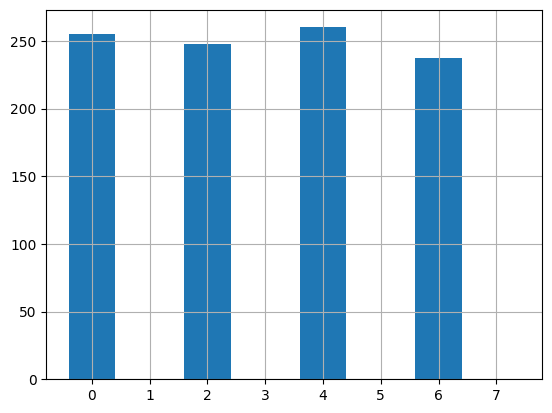

In [41]:
simulare_multipla_cerc(1000, 30, 0.6, 8)

In [1]:
from scipy.stats import hypergeom, geom
import numpy as np

n=49
n1=6
n2=6

def simulare(size):
    prob_castig=sum([hypergeom.pmf(k,n,n1,n2) for k in range(3,7)])

    bilete_necastigatoare=geom.rvs(prob_castig,size=size)-1

    return bilete_necastigatoare

In [4]:
rez = simulare(2)
print(rez)

[24 25]


In [9]:
def cerinta_ii(num_simulari=1000):
    p = sum(hypergeom.pmf(k, 49, 6, 6) for k in range(3, 7))

    prob_teoretica = (1 - p)**10

    mostre = simulare(num_simulari)
    prob_simulare = np.mean(mostre >= 10)

    return prob_teoretica, prob_simulare

In [10]:
pt, ps = cerinta_ii()
print("Teoretica", pt)
print("Simulare:", ps)

Teoretica 0.82850357564066
Simulare: 0.834
